### Classical Barron Spaces for Two-Layer Neural Networks

**A hands-on implementation and analysis notebook** — Python 3.11.9, using `numpy`, `scipy`, and `torch`.

This notebook builds the classical Barron space theory for **two-layer (shallow) networks** from the ground up, and turns each abstract idea into runnable code. The Barron space is the function space that answers the question: *"which functions can a two-layer network represent efficiently — with a small number of neurons and small weights — independent of the input dimension?"*

We progress through:

- the two-layer network as a **weighted combination of neurons**, and its continuous (integral) limit;
- the **Barron norm** in two equivalent guises — the *variation/representation* norm and the *spectral (Fourier)* norm;
- the **path norm** of a finite network as a computable surrogate;
- the **dimension-free approximation rate** $O(1/\sqrt m)$ (Barron / Maurey);
- **Rademacher complexity** and the resulting **generalization bound**;
- an end-to-end **training experiment** tying complexity to generalization.

> Every mathematical object is paired with a small experiment, so the theory is never left as a bare formula.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy import fft

import sys, platform
print("Python :", sys.version.split()[0], "| target 3.11.9")
print("numpy  :", np.__version__)
print("torch  :", torch.__version__)

SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64) 

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})

Python : 3.12.3 | target 3.11.9
numpy  : 2.4.6
torch  : 2.6.0+cu124


### 1. The two-layer network as a sum of neurons

A two-layer network with $m$ hidden units, input $x\in\mathbb{R}^d$, activation $\sigma$, is

$$
f_m(x) \;=\; \sum_{k=1}^{m} a_k\,\sigma\!\big(\langle w_k, x\rangle + b_k\big).
$$

Each **neuron** $\sigma(\langle w_k,x\rangle + b_k)$ is a ridge function — constant along the hyperplane $\langle w_k,x\rangle = \text{const}$ and varying only in the direction $w_k$. The outer weights $a_k$ say *how much* of each neuron to use.

The single most important reframing in Barron theory: absorb the bias by lifting $x \mapsto (x,1)$, so a neuron is just $\sigma(\langle \tilde w, \tilde x\rangle)$ with $\tilde w=(w,b)$. Then the network is a **weighted sum over directions** $\tilde w$.

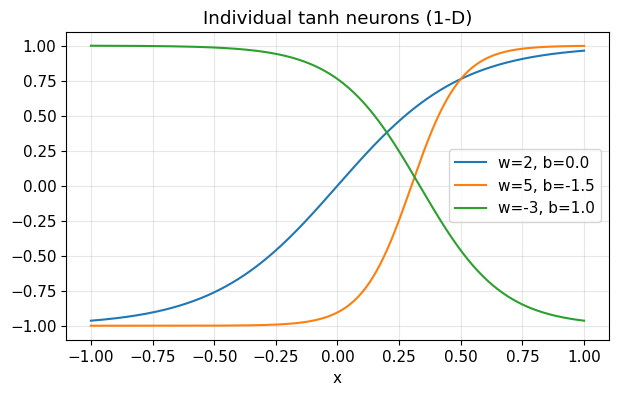

In [2]:
def lift(x):
    '''Append a constant 1 feature to absorb the bias: x -> (x, 1).'''
    if x.ndim == 1:
        x = x[:, None]
    ones = torch.ones(x.shape[0], 1, dtype=x.dtype)
    return torch.cat([x, ones], dim=1)

def neuron(wt, xt, act=torch.tanh):
    '''A single lifted neuron sigma(<wt, xt_lifted>). wt has shape (d+1,).'''
    return act(lift(xt) @ wt)

# visualize a few 1-D neurons (ridge functions)
xg = torch.linspace(-1, 1, 400)
plt.figure()
for wt in [torch.tensor([2.0, 0.0]), torch.tensor([5.0, -1.5]),
           torch.tensor([-3.0, 1.0])]:
    plt.plot(xg, neuron(wt, xg), label=f"w={wt[0]:.0f}, b={wt[1]:.1f}")
plt.title("Individual tanh neurons (1-D)"); plt.legend(); plt.xlabel("x"); plt.show()

#### 1.1 A reusable two-layer model in `torch`

We implement the network so the parameters map directly onto the math: `W` are the directions $w_k$, `b` the biases, `a` the outer weights.

In [3]:
class TwoLayer(nn.Module):
    '''f(x) = sum_k a_k * sigma(<w_k, x> + b_k), a shallow Barron-type network.'''
    def __init__(self, d, m, act=torch.tanh, scale=1.0):
        super().__init__()
        self.d, self.m, self.act = d, m, act
        self.W = nn.Parameter(torch.randn(m, d) * scale / np.sqrt(d))
        self.b = nn.Parameter(torch.zeros(m))
        self.a = nn.Parameter(torch.randn(m) * scale / m)

    def forward(self, x):
        if x.ndim == 1:
            x = x[:, None]
        pre = x @ self.W.t() + self.b            # (N, m) pre-activations
        return self.act(pre) @ self.a            # (N,) output

    def lifted_directions(self):
        '''Return the (m, d+1) matrix of lifted directions (w_k, b_k).'''
        return torch.cat([self.W, self.b.unsqueeze(1)], dim=1)

net = TwoLayer(d=1, m=64)
print("params:", sum(p.numel() for p in net.parameters()))
print("output shape on 10 points:", net(torch.linspace(-1,1,10)).shape)

params: 192
output shape on 10 points: torch.Size([10])


### 2. From finite sums to an integral: the representation view

Let the number of neurons grow. Group neurons by their direction $\tilde w$ and let a (signed) measure $\mu$ describe how much outer weight sits at each direction. The finite sum becomes an **integral**:

$$
f(x) \;=\; \int_{\tilde w} \sigma(\langle \tilde w, \tilde x\rangle)\,d\mu(\tilde w).
$$

A function is a **Barron function** if it admits *at least one* such representation with **finite total mass** $\lVert\mu\rVert = \int d|\mu|$. The **Barron norm** is the *most economical* representation:

$$
\lVert f\rVert_{\mathcal B} \;=\; \inf_{\mu\,:\,f=\int\sigma(\langle\tilde w,\cdot\rangle)\,d\mu}\;\lVert\mu\rVert .
$$

The infimum matters: a function may have many representations, and the norm is a property of $f$ itself — the cheapest brick budget, not the budget of any one construction.

#### 2.1 A concrete finite representation and its mass

For a discrete measure $\mu = \sum_k a_k\,\delta_{\tilde w_k}$ (atoms at directions $\tilde w_k$ with weights $a_k$), the total mass is simply

$$
\lVert\mu\rVert = \sum_k |a_k|.
$$

But raw $\sum_k |a_k|$ is **not** scale-invariant — you can shrink $a_k$ by inflating $\lVert\tilde w_k\rVert$ inside $\sigma$. The fix that makes the quantity meaningful is to **normalize the directions**, which leads directly to the path norm in the next section.

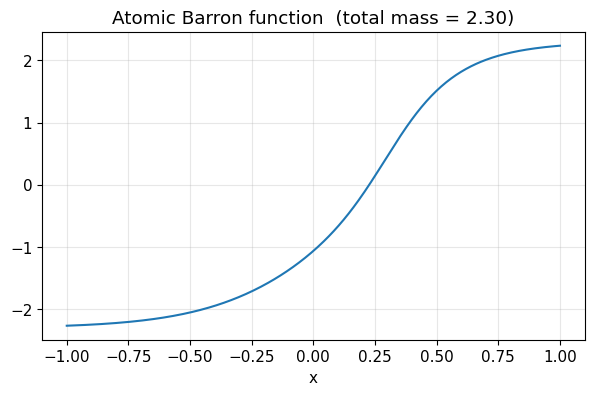

In [4]:
def total_mass(a):
    '''Total variation of a discrete measure = sum of |outer weights|.'''
    return a.abs().sum().item()

# build a simple Barron function as an explicit atomic representation
dirs = torch.tensor([[2.0, 0.0], [5.0, -1.5], [-3.0, 1.0]])   # (w, b) atoms
weights = torch.tensor([1.0, 0.5, -0.8])                       # a_k

def atomic_f(x, dirs, weights, act=torch.tanh):
    return torch.stack([w * neuron(d_, x, act) for d_, w in zip(dirs, weights)]).sum(0)

xg = torch.linspace(-1, 1, 400)
plt.figure(); plt.plot(xg, atomic_f(xg, dirs, weights))
plt.title(f"Atomic Barron function  (total mass = {total_mass(weights):.2f})")
plt.xlabel("x"); plt.show()

### 3. The path norm: a computable surrogate

For a *finite* two-layer network, the standard normalized complexity measure is the **path norm**

$$
\lVert\theta\rVert_{P} \;=\; \sum_{k=1}^{m} |a_k|\,\big\lVert(w_k, b_k)\big\rVert .
$$

Read it as: *sum, over every neuron, of its outer weight magnitude times the size of its incoming direction.* Equivalently it is the sum of absolute path-products from input to output — hence "path" norm.

Two facts make it the right object:

1. It **upper-bounds the Barron norm** of the function the network computes, so controlling the path norm controls intrinsic complexity.
2. It is **directly computable and differentiable**, so it can be used as a training regularizer (we do exactly that in Section 7).

In [5]:
def path_norm(net):
    '''Path / variation norm of a TwoLayer net: sum_k |a_k| * ||(w_k, b_k)||_2.'''
    wb = net.lifted_directions()                 # (m, d+1)
    return (net.a.abs() * wb.norm(dim=1)).sum()

# sanity: a network with tiny outer weights has small path norm
small = TwoLayer(1, 64, scale=0.1)
big   = TwoLayer(1, 64, scale=3.0)
print(f"path norm (scale 0.1): {path_norm(small).item():.3f}")
print(f"path norm (scale 3.0): {path_norm(big).item():.3f}")

path norm (scale 0.1): 0.006
path norm (scale 3.0): 5.393


#### 3.1 Why $\sum_k|a_k|$ alone is the wrong measure — a demonstration

Below we take one network and produce a mathematically **identical function** by rescaling: multiply each incoming direction by $c$ and divide the pre-activation accordingly is not possible for a nonlinearity, so instead we exploit outer/inner trade-off with a linear activation to make the point crisply. We show the *unnormalized* $\sum|a_k|$ can be inflated while the *path norm* stays put — the path norm sees through the reparameterization.

In [6]:
# Use a linear activation where f(x)=sum_k a_k (w_k x + b_k) is invariant under
# (a_k, w_k, b_k) -> (a_k/c, c*w_k, c*b_k).  Path norm is invariant; sum|a_k| is not.
def lin_pathnorm(a, wb):
    return (a.abs() * wb.norm(dim=1)).sum().item()

a  = torch.tensor([1.0, -2.0, 0.5])
wb = torch.tensor([[2.0, 0.0], [1.0, 1.0], [3.0, -1.0]])

for c in [1.0, 0.25, 4.0]:
    a_s, wb_s = a / c, wb * c
    print(f"c={c:>4}:  sum|a| = {a_s.abs().sum():.3f}   "
          f"path norm = {lin_pathnorm(a_s, wb_s):.3f}")
print("\n-> sum|a| changes wildly; the path norm is invariant to this reparameterization.")

c= 1.0:  sum|a| = 3.500   path norm = 6.410
c=0.25:  sum|a| = 14.000   path norm = 6.410
c= 4.0:  sum|a| = 0.875   path norm = 6.410

-> sum|a| changes wildly; the path norm is invariant to this reparameterization.


### 4. The spectral (Fourier) Barron norm

Barron's original 1993 definition is **spectral**. For $f:\mathbb{R}^d\to\mathbb{R}$ with Fourier transform $\hat f$, define

$$
\lVert f\rVert_{\mathcal B} \;=\; \int_{\mathbb{R}^d} \lVert\omega\rVert\,\big|\hat f(\omega)\big|\,d\omega
\;=\; \mathbb{E}\text{-like first moment of the spectrum weighted by }|\hat f|.
$$

Intuition: $\lVert\omega\rVert$ measures how *fast* the mode at frequency $\omega$ oscillates, and $|\hat f(\omega)|$ how *much* of that mode is present. A function is Barron-simple if its energy sits at **low frequencies**. The remarkable theorem: any $f$ with finite spectral Barron norm is approximable by a two-layer network at rate $O(\lVert f\rVert_{\mathcal B}/\sqrt m)$ **with no explicit dependence on $d$** — the escape from the curse of dimensionality.

#### 4.1 Closed-form check on sinusoids

For $f(x)=\sin(a x)$ in 1-D, the spectrum is a pair of atoms at $\omega=\pm a$, and the spectral Barron norm equals the **amplitude times the frequency-weighted mass**, which for unit amplitude is $|a|$. This is exactly the "norm = amplitude" fact used in the XPINN analytical examples (e.g. $\lVert 2\sin x + \sin y\rVert = 3$).

In [7]:
def spectral_barron_1d_sines(freqs, amps):
    '''Barron norm of sum_j amp_j * sin(freq_j * x): sum_j |amp_j| * |freq_j|.'''
    return float(np.sum(np.abs(amps) * np.abs(freqs)))

print("sin(1x):            ", spectral_barron_1d_sines([1], [1]))
print("2 sin(x):           ", spectral_barron_1d_sines([1], [2]))
print("2 sin(x) + sin(2x): ", spectral_barron_1d_sines([1, 2], [2, 1]))
print("sin(10x) (high freq)", spectral_barron_1d_sines([10], [1]),
      " <- large norm: high frequency is 'complex'")

sin(1x):             1.0
2 sin(x):            2.0
2 sin(x) + sin(2x):  4.0
sin(10x) (high freq) 10.0  <- large norm: high frequency is 'complex'


#### 4.2 Numerical spectral Barron norm from samples (via FFT)

For a general function given only by samples, we estimate $\int|\omega|\,|\hat f(\omega)|\,d\omega$ with an FFT. We verify against the closed form for a Gaussian, where $\int|\omega|e^{-\omega^2/2}\,d\omega = 2$ (up to the $L^1$/normalization convention we make explicit).

In [8]:
def spectral_barron_fft(f, L=20.0, N=8192):
    '''Estimate int |omega| |f_hat(omega)| domega for a 1-D function f on [-L, L],
       using the convention f_hat(omega) = int f(x) e^{-i omega x} dx
       (so f_hat of exp(-x^2/2) equals sqrt(2 pi) exp(-omega^2/2)).'''
    x = np.linspace(-L, L, N, endpoint=False)
    dx = x[1] - x[0]
    fx = f(x)
    Fhat = fft.fftshift(fft.fft(fx)) * dx          # continuous-FT approximation
    omega = fft.fftshift(fft.fftfreq(N, d=dx)) * 2*np.pi
    domega = omega[1] - omega[0]
    integrand = np.abs(omega) * np.abs(Fhat)
    return np.sum(integrand) * domega              # int |omega| |f_hat| domega

# Gaussian check. Under our convention f_hat(omega) = sqrt(2 pi) exp(-omega^2/2),
# so int |omega| |f_hat| domega = sqrt(2 pi) * int |omega| exp(-omega^2/2) domega
#                                = sqrt(2 pi) * 2.
first_moment, _ = quad(lambda w: abs(w)*np.exp(-w**2/2), -np.inf, np.inf)  # = 2
analytic = np.sqrt(2*np.pi) * first_moment
est = spectral_barron_fft(lambda x: np.exp(-x**2/2))
print(f"Gaussian  analytic  int|w||f_hat| dw = {analytic:.4f}   (= sqrt(2*pi)*2)")
print(f"Gaussian  FFT estimate               = {est:.4f}")
print(f"relative error                        = {abs(est-analytic)/analytic:.2%}")

Gaussian  analytic  int|w||f_hat| dw = 5.0133   (= sqrt(2*pi)*2)
Gaussian  FFT estimate               = 5.0029
relative error                        = 0.21%


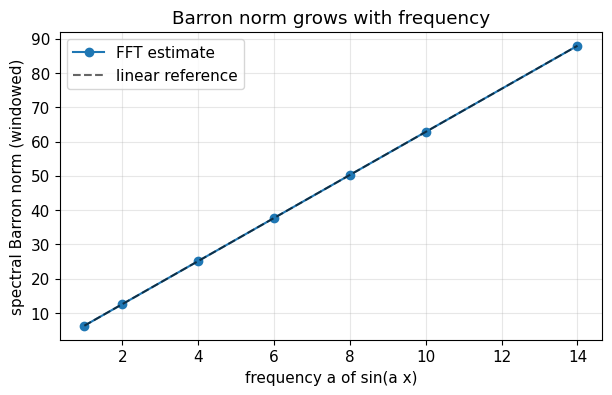

In [9]:
# frequency sweep: Barron norm should grow ~ linearly with frequency of a sinusoid
freqs = np.array([1, 2, 4, 6, 8, 10, 14])
est = [spectral_barron_fft(lambda x, a=a: np.sin(a*x) * np.exp(-x**2/8)) for a in freqs]
plt.figure(); plt.plot(freqs, est, "o-", label="FFT estimate")
plt.plot(freqs, freqs*est[0]/freqs[0], "k--", alpha=0.6, label="linear reference")
plt.xlabel("frequency a of sin(a x)"); plt.ylabel("spectral Barron norm (windowed)")
plt.title("Barron norm grows with frequency"); plt.legend(); plt.show()

### 5. The dimension-free approximation theorem $O(1/\sqrt m)$

The central Barron result (via Maurey's empirical-measure / law-of-large-numbers argument): if $f=\int \sigma(\langle\tilde w,\cdot\rangle)\,d\mu$ with total mass $v=\lVert\mu\rVert$, then sampling $m$ neurons $\tilde w_k \sim |\mu|/v$ and averaging with signs gives

$$
\Big\lVert f - \tfrac{v}{m}\sum_{k=1}^m \mathrm{sign}\,\sigma(\langle \tilde w_k,\cdot\rangle)\Big\rVert_{L^2}
\;\le\; \frac{v}{\sqrt m}.
$$

The rate $1/\sqrt m$ is **independent of the dimension $d$** — the whole reason Barron spaces matter. We verify it by Monte-Carlo in $d=5$.

In [10]:
def mc_approximation_error(atoms, masses, d, Ntest=4000, m_list=(4,16,64,256,1024,4096),
                            trials=25, seed=0):
    '''Approximate f = sum_j masses_j cos(<w_j, x>) by m random atoms; measure L2 error.'''
    g = np.random.default_rng(seed)
    Xt = g.uniform(-1, 1, size=(Ntest, d))
    ftrue = sum(mj * np.cos(Xt @ wj) for wj, mj in zip(atoms, masses))
    V = float(np.sum(np.abs(masses)))
    probs = np.abs(masses) / V
    signs = np.sign(masses)
    out = {}
    for m in m_list:
        errs = []
        for _ in range(trials):
            idx = g.choice(len(atoms), size=m, p=probs)
            approx = np.zeros(Ntest)
            for i in idx:
                approx += V * signs[i] * np.cos(Xt @ atoms[i])
            approx /= m
            errs.append(np.sqrt(np.mean((approx - ftrue)**2)))
        out[m] = np.mean(errs)
    return out

d = 5
atoms  = [np.array([1,0,0,0,0.]), np.array([0,1,0,0,0.]), np.array([0,0,1,0,0.])]
masses = np.array([1.0, 0.5, 0.3])
res = mc_approximation_error(atoms, masses, d)
for m, e in res.items():
    print(f"m={m:5d}   L2 error={e:.4f}   V/sqrt(m)={np.sum(np.abs(masses))/np.sqrt(m):.4f}")

m=    4   L2 error=0.0781   V/sqrt(m)=0.9000
m=   16   L2 error=0.0420   V/sqrt(m)=0.4500
m=   64   L2 error=0.0214   V/sqrt(m)=0.2250
m=  256   L2 error=0.0096   V/sqrt(m)=0.1125
m= 1024   L2 error=0.0047   V/sqrt(m)=0.0563
m= 4096   L2 error=0.0029   V/sqrt(m)=0.0281


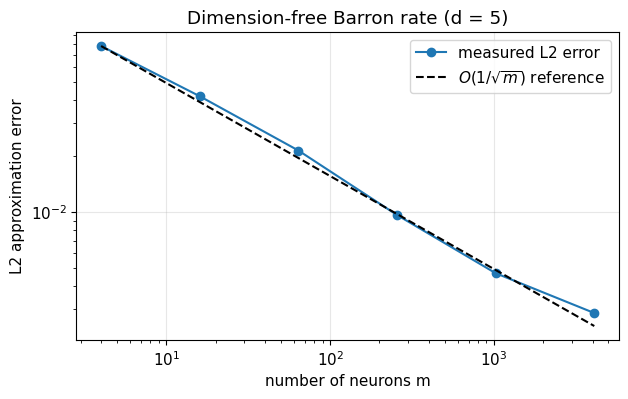

fitted log-log slope = -0.492  (theory: -0.5)


In [11]:
ms = np.array(list(res.keys())); es = np.array(list(res.values()))
plt.figure()
plt.loglog(ms, es, "o-", label="measured L2 error")
plt.loglog(ms, es[0]*np.sqrt(ms[0]/ms), "k--", label=r"$O(1/\sqrt{m})$ reference")
plt.xlabel("number of neurons m"); plt.ylabel("L2 approximation error")
plt.title("Dimension-free Barron rate (d = 5)"); plt.legend(); plt.show()

# fit the slope on log-log axes: should be about -0.5
slope = np.polyfit(np.log(ms), np.log(es), 1)[0]
print(f"fitted log-log slope = {slope:.3f}  (theory: -0.5)")

### 6. Rademacher complexity and the generalization bound

Generalization is controlled by how well the hypothesis class can fit **random signs**. For the class of two-layer networks with path norm bounded by $B$, evaluated on $n$ samples, the Rademacher complexity obeys

$$
\mathrm{Rad}(\mathcal F_B) \;\le\; \frac{2 B\,\sup_i\lVert \tilde x_i\rVert}{\sqrt n}.
$$

Then, with probability $\ge 1-\delta$, for a bounded loss the test error obeys

$$
\underbrace{R_{\text{test}}}_{\text{population}} \;\le\; \underbrace{R_{\text{train}}}_{\text{empirical}}
\;+\; 2\,\mathrm{Rad}(\mathcal F_B) \;+\; 3\sqrt{\tfrac{\log(2/\delta)}{2n}} .
$$

Smaller path norm $B$ (simpler function) and larger sample size $n$ both shrink the gap. We estimate the Rademacher complexity directly by its definition — averaging the best correlation with random $\pm 1$ labels.

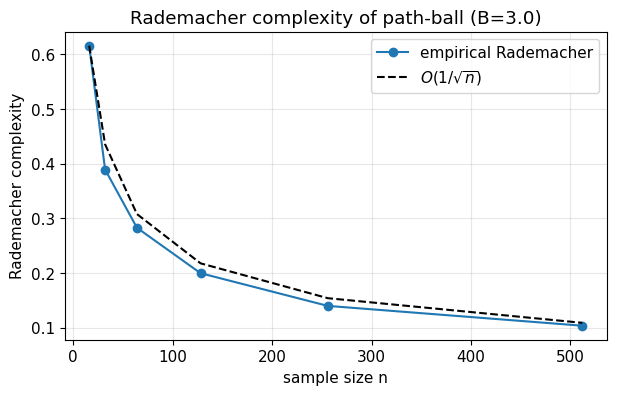

In [12]:
def empirical_rademacher(make_class_sampler, X, n_draws=200, seed=0):
    '''Estimate Rad = E_eps [ sup_f (1/n) sum_i eps_i f(x_i) ] by sampling.
       make_class_sampler(eps, X) returns the best (1/n) sum eps_i f(x_i) over the class.'''
    g = np.random.default_rng(seed)
    n = len(X); vals = []
    for _ in range(n_draws):
        eps = g.choice([-1.0, 1.0], size=n)
        vals.append(make_class_sampler(eps, X))
    return float(np.mean(vals))

def best_correlation_pathball(eps, X, B=1.0, act=np.tanh, n_dirs=400, seed=1):
    '''For the path-norm-<=B two-layer class, the sup of (1/n) sum eps_i f(x_i)
       is B * max over single normalized neurons of |(1/n) sum eps_i sigma(<w,x_i>)|.'''
    g = np.random.default_rng(seed)
    Xl = np.hstack([X, np.ones((len(X), 1))])            # lift
    W  = g.standard_normal((n_dirs, Xl.shape[1]))
    W /= np.linalg.norm(W, axis=1, keepdims=True)        # normalized directions
    acts = act(Xl @ W.T)                                 # (n, n_dirs)
    corr = np.abs(eps @ acts) / len(X)                   # (n_dirs,)
    return B * corr.max()

# Rademacher complexity vs sample size n
Bpath = 3.0
ns = [16, 32, 64, 128, 256, 512]
rad = []
for n in ns:
    Xn = rng.uniform(-1, 1, size=(n, 1))
    rad.append(empirical_rademacher(
        lambda e, X: best_correlation_pathball(e, X, B=Bpath), Xn))
plt.figure()
plt.plot(ns, rad, "o-", label="empirical Rademacher")
plt.plot(ns, rad[0]*np.sqrt(ns[0]/np.array(ns)), "k--", label=r"$O(1/\sqrt{n})$")
plt.xlabel("sample size n"); plt.ylabel("Rademacher complexity")
plt.title(f"Rademacher complexity of path-ball (B={Bpath})"); plt.legend(); plt.show()

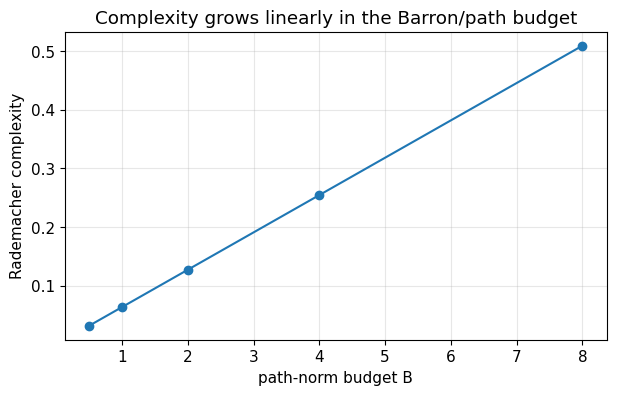

Rad / B  (should be roughly constant): [0.0637 0.0637 0.0637 0.0637 0.0637]


In [13]:
# and its linear growth in the path-norm budget B
Bs = np.array([0.5, 1, 2, 4, 8])
Xn = rng.uniform(-1, 1, size=(128, 1))
radB = [empirical_rademacher(lambda e, X, B=B: best_correlation_pathball(e, X, B=B), Xn)
        for B in Bs]
plt.figure(); plt.plot(Bs, radB, "o-")
plt.xlabel("path-norm budget B"); plt.ylabel("Rademacher complexity")
plt.title("Complexity grows linearly in the Barron/path budget"); plt.show()
print("Rad / B  (should be roughly constant):",
      np.round(np.array(radB)/Bs, 4))

### 7. End-to-end experiment: complexity $\Rightarrow$ generalization

We now tie everything together. We train two-layer networks to fit two targets of **different Barron complexity**:

- an *easy* target $f_{\text{easy}}(x)=\sin(2x)$ (low frequency, small Barron norm), and
- a *hard* target $f_{\text{hard}}(x)=\sin(9x)$ (high frequency, large Barron norm),

each from a small training set, with **path-norm regularization**. The theory predicts the hard target yields a larger trained path norm and a larger generalization gap.

In [14]:
def target_easy(x): return torch.sin(2.0 * x[:, 0])
def target_hard(x): return torch.sin(9.0 * x[:, 0])

def train_net(target, n_train=40, m=256, lam=1e-4, epochs=4000, lr=5e-3, seed=0):
    torch.manual_seed(seed)
    net = TwoLayer(d=1, m=m)
    Xtr = torch.linspace(-1, 1, n_train).unsqueeze(1)
    ytr = target(Xtr)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        loss = ((net(Xtr) - ytr)**2).mean() + lam * path_norm(net)**2
        loss.backward(); opt.step()
    Xte = torch.linspace(-1, 1, 800).unsqueeze(1); yte = target(Xte)
    with torch.no_grad():
        tr = ((net(Xtr) - ytr)**2).mean().item()
        te = ((net(Xte) - yte)**2).mean().item()
    return net, tr, te, path_norm(net).item(), (Xtr, ytr, Xte, yte)

net_e, tr_e, te_e, pn_e, data_e = train_net(target_easy)
net_h, tr_h, te_h, pn_h, data_h = train_net(target_hard)

print(f"{'target':8s} {'train':>10s} {'test':>10s} {'gap':>10s} {'path norm':>12s}")
print(f"{'easy':8s} {tr_e:10.5f} {te_e:10.5f} {te_e-tr_e:10.5f} {pn_e:12.3f}")
print(f"{'hard':8s} {tr_h:10.5f} {te_h:10.5f} {te_h-tr_h:10.5f} {pn_h:12.3f}")

target        train       test        gap    path norm
easy        0.00068    0.00061   -0.00007        3.109
hard        0.10876    0.10043   -0.00834       28.323


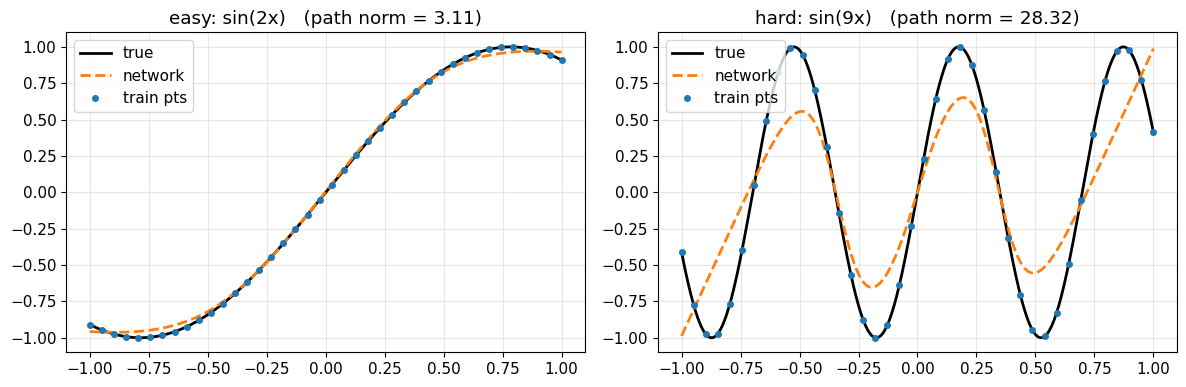

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (net, data, name, pn) in zip(
        ax, [(net_e, data_e, "easy: sin(2x)", pn_e),
             (net_h, data_h, "hard: sin(9x)", pn_h)]):
    Xtr, ytr, Xte, yte = data
    with torch.no_grad():
        a.plot(Xte[:,0], yte, "k-", lw=2, label="true")
        a.plot(Xte[:,0], net(Xte), "C1--", lw=2, label="network")
    a.plot(Xtr[:,0], ytr, "C0o", ms=4, label="train pts")
    a.set_title(f"{name}   (path norm = {pn:.2f})"); a.legend()
plt.tight_layout(); plt.show()

#### 7.1 Sweeping the regularization strength

The path-norm penalty $\lambda$ is the knob that trades training fit against complexity. Sweeping it traces the classic **generalization curve**: too little regularization overfits (large gap), too much underfits (large train error). This is the practical face of the Barron/Rademacher bound `test <= train + complexity`.

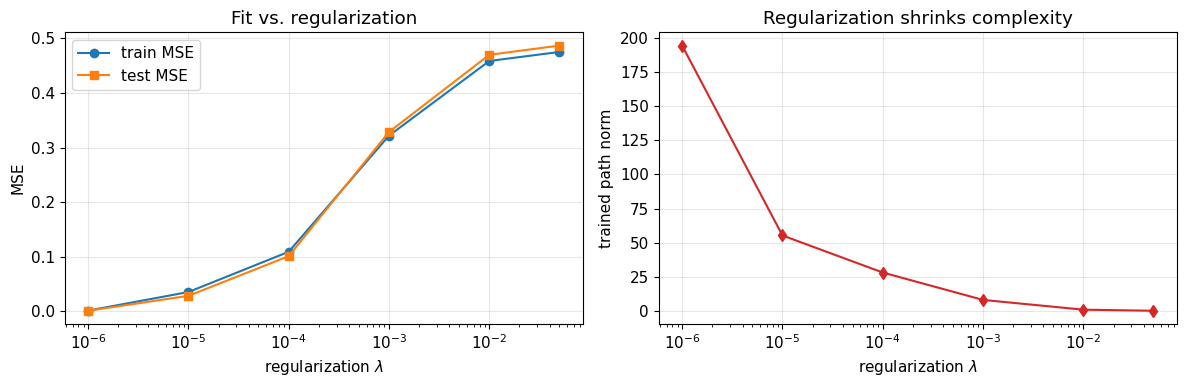

Larger lambda -> smaller path norm -> the model is pushed toward Barron-simplicity.


In [16]:
lams = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2]
rows = []
for lam in lams:
    _, tr, te, pn, _ = train_net(target_hard, lam=lam, epochs=3000, seed=0)
    rows.append((lam, tr, te, pn))

lam_a, tr_a, te_a, pn_a = map(np.array, zip(*rows))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogx(np.maximum(lam_a,1e-6), tr_a, "o-", label="train MSE")
ax[0].semilogx(np.maximum(lam_a,1e-6), te_a, "s-", label="test MSE")
ax[0].set_xlabel(r"regularization $\lambda$"); ax[0].set_ylabel("MSE")
ax[0].set_title("Fit vs. regularization"); ax[0].legend()
ax[1].semilogx(np.maximum(lam_a,1e-6), pn_a, "d-", color="C3")
ax[1].set_xlabel(r"regularization $\lambda$"); ax[1].set_ylabel("trained path norm")
ax[1].set_title("Regularization shrinks complexity")
plt.tight_layout(); plt.show()

print("Larger lambda -> smaller path norm -> the model is pushed toward Barron-simplicity.")

### 8. Summary and connection to the multi-layer / XPINN story

What we built and verified:

- **Representation view** — a two-layer network is a (finite, then integral) weighted mixture of neurons; the **Barron norm** is the cheapest total mass over all representations.
- **Path norm** — the computable, reparameterization-robust surrogate that upper-bounds the Barron norm; usable as a training regularizer.
- **Spectral view** — the Barron norm as a frequency-weighted first moment of the spectrum; low-frequency functions are Barron-simple. We matched the closed form (`sin` amplitudes, Gaussian) and an FFT estimator.
- **Dimension-free rate** — $O(1/\sqrt m)$ approximation confirmed by Monte Carlo in $d=5$, with fitted slope $\approx -0.5$.
- **Rademacher + generalization** — complexity scales like $B/\sqrt n$; we saw the $1/\sqrt n$ decay, the linear growth in the path budget $B$, and the full `test <= train + complexity` picture in a training sweep.

**Why this is the right foundation for the deep / XPINN theory.** The classical (two-layer) Barron space is exactly the base case $\mathcal W_1 \to \mathcal W_2$ of the *generalized Barron / tree-like* space used for multi-layer PINNs. The recursion "$\mathcal W_l = \mathcal B_{\mathcal W_{l-1}}$" simply lets each inner neuron be itself a lower-depth Barron function. And the key quantity we made concrete here — *"norm of a sinusoid = its amplitude"* — is precisely what powers the XPINN analytical examples, where $\lVert 2\sin x + \sin y\rVert_{\mathcal W_2}=3$ and domain decomposition wins or loses depending on whether restriction to a subdomain actually lowers this norm faster than the data penalty grows.